Data Cleaning 8 raw datasets


Cleaning of olist_geolocation_dataset and olist_customers_dataset

In [1]:
import numpy as np
import pandas as pd

In [2]:
#reading the datasets
geo = pd.read_csv("data/olist_geolocation_dataset.csv", sep=',')
customers = pd.read_csv("data/olist_customers_dataset.csv", sep=',')

In [3]:
#shapes 
geo.shape
print(f"Geo shape: {geo.shape}")
customers.shape
print(f"customers shape: {customers.shape}")

Geo shape: (1000163, 5)
customers shape: (99441, 5)


In [4]:
geo.head(3)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP


In [5]:
customers.head(3)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


In [6]:
#checking for duplicates
geo_d=geo.duplicated().sum()
print(f"Total duplicates in geo: {geo_d}")
##duplicated not dropped here, cleaning for geo is done below where the the lat and lng is aggregated

customers_d = customers.duplicated().sum()
print(f"Total duplicate in customers: {customers_d}")

Total duplicates in geo: 261831
Total duplicate in customers: 0


In [7]:
customers.isnull().sum() # no null values across the whole dataset

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [8]:
geo.isnull().sum() #no null value acrros thw whole dataset

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Data Cleaning of olist_order_items_dataset and olist_order_payments_dataset

In [9]:
#reading the datasets 
order_items = pd.read_csv("data/olist_order_items_dataset.csv", sep=',')
order_payments = pd.read_csv("data/olist_order_payments_dataset.csv", sep=',')

In [10]:
#shapes
order_items.shape
print(f"order_items shape: {order_items.shape}")
order_payments.shape
print(f"order_payments shape: {order_payments.shape}")

order_items shape: (112650, 7)
order_payments shape: (103886, 5)


In [11]:
order_items.head(3)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


In [12]:
order_payments.head(3)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


In [13]:
order_items_d = order_items.duplicated().sum()
print(f"order_items duplicates: {order_items_d}")
order_payments_d = order_payments.duplicated().sum()
print(f"order_payments duplicates: {order_payments_d}")

order_items duplicates: 0
order_payments duplicates: 0


In [14]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [15]:
order_payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Data Preparation of olist_products_dataset and olist_sellers_dataset


In [16]:
#reading the datasets 
product_df = pd.read_csv("data/olist_products_dataset.csv", sep=',')
seller_df = pd.read_csv("data/olist_sellers_dataset.csv", sep=',')

In [17]:
#shapes 
product_df.shape
print(f"product_df shape: {product_df.shape}")
seller_df.shape
print(f"seller_df shape: {seller_df.shape}")

product_df shape: (32951, 9)
seller_df shape: (3095, 4)


In [18]:
product_df.head(3)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


In [19]:
seller_df.head(3)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


In [20]:
product_df_d = product_df.duplicated().sum()
print(f"product_df duplicates: {product_df_d}")
seller_df_d = seller_df.duplicated().sum()
print(f"seller_df duplicates: {seller_df_d}")

product_df duplicates: 0
seller_df duplicates: 0


In [21]:
product_df.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [22]:
product_df = product_df.dropna()
product_df.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [23]:
seller_df.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Data cleaning of olist_orders_dataset and olist_order_reviews_dataset

In [24]:
#reading dataset
order = pd.read_csv('data/olist_orders_dataset.csv', sep=',')
order_rev = pd.read_csv('data/olist_order_reviews_dataset.csv', sep=',')

In [25]:
#shapes 
order.shape
print(f"order shape: {order.shape}")
order_rev.shape
print(f"order_rev shape: {order_rev.shape}")

order shape: (99441, 8)
order_rev shape: (99224, 7)


In [26]:
order.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [27]:
order_rev.head(3)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


In [28]:
#checking for dups
order_d = order.duplicated().sum()
print(f"order duplicates: {order_d}")
order_rev_d = order_rev.duplicated().sum()
print(f"order_rev duplicates: {order_rev_d}")

order duplicates: 0
order_rev duplicates: 0


In [29]:
order.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [30]:
# 2. Parse each timestamp column into real datetimes
ts_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in ts_cols:
    order[col] = pd.to_datetime(order[col], errors="coerce")


In [31]:
order = order.dropna(subset=["order_purchase_timestamp"])

In [32]:
for col in ["review_creation_date", "review_answer_timestamp"]:
    order_rev[col] = pd.to_datetime(order_rev[col], errors="coerce")

In [33]:
order_rev["review_score"] = order_rev["review_score"].astype(int) #make sure review score is int

In [34]:
order_rev.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [35]:
#dropping both columns with high null value
order_rev_clean = order_rev.drop(columns=["review_comment_title", "review_comment_message"])

In [36]:
order_rev_clean.head(5)

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,2018-03-01,2018-03-02 10:26:53


In [37]:
order_rev_clean = order_rev_clean.sort_values(by='review_score', ascending=False)
order_rev_clean.head()

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,2018-03-22,2018-03-23 09:10:43
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,2017-12-09,2017-12-11 20:06:42
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,2017-04-21,2017-04-21 22:02:06


In [38]:
# Step-by-step merging on 'order_id'

# 1. Merge orders with order_items
merged_df = pd.merge(order, order_items, on='order_id', how='inner')

# 2. Merge the result with order_payments
merged_df = pd.merge(merged_df, order_payments, on='order_id', how='inner')

# 3. Merge the result with order_reviews
merged_df = pd.merge(merged_df, order_rev_clean, on='order_id', how='inner')

print("✅ Final Merged Shape:", merged_df.shape)

merged_df.head()

✅ Final Merged Shape: (117329, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,29.99,8.72,1,credit_card,1,18.12,a54f0611adc9ed256b57ede6b6eb5114,4,2017-10-11,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,29.99,8.72,3,voucher,1,2.00,a54f0611adc9ed256b57ede6b6eb5114,4,2017-10-11,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,29.99,8.72,2,voucher,1,18.59,a54f0611adc9ed256b57ede6b6eb5114,4,2017-10-11,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,118.70,22.76,1,boleto,1,141.46,8d5266042046a06655c8db133d120ba5,4,2018-08-08,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,159.90,19.22,1,credit_card,3,179.12,e73b67b67587f7644d5bd1a52deb1b01,5,2018-08-18,2018-08-22 19:07:58


In [39]:
# Step 4: Merge with products (via product_id)
merged_df = pd.merge(merged_df, product_df, on='product_id', how='inner')

# Step 5: Merge with sellers (via seller_id)
merged_df = pd.merge(merged_df, seller_df, on='seller_id', how='inner')

# Step 6: Merge with customers (via customer_id)
merged_df = pd.merge(merged_df, customers, on='customer_id', how='inner')

# Final check
print("✅ Final Merged Shape:", merged_df.shape)

merged_df.head()


✅ Final Merged Shape: (115633, 37)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,9350,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,9350,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,9350,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,19.0,13.0,19.0,31570,belo horizonte,SP,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,24.0,19.0,21.0,14840,guariba,SP,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [40]:
# Export the final merged DataFrame to a CSV file
merged_df.to_csv("final_merged_olist_dataset.csv", index=False)

In [41]:
merged_df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,9350,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,9350,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,9350,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,19.0,13.0,19.0,31570,belo horizonte,SP,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,24.0,19.0,21.0,14840,guariba,SP,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [42]:
geo_summary = geo.groupby("geolocation_zip_code_prefix", as_index=False).agg({
    "geolocation_lat": "mean",
    "geolocation_lng": "mean"
}).rename(columns={
    "geolocation_zip_code_prefix": "zip_code_prefix",
    "geolocation_lat": "avg_lat",
    "geolocation_lng": "avg_lng"
})

# Preview result
print("✅ Aggregated Geolocation Data (1 row per zip):", geo_summary.shape)
geo_summary.head()

✅ Aggregated Geolocation Data (1 row per zip): (19015, 3)


,zip_code_prefix,avg_lat,avg_lng
0,1001,-23.550190,-46.634024
1,1002,-23.548146,-46.634979
2,1003,-23.548994,-46.635731
3,1004,-23.549799,-46.634757
4,1005,-23.549456,-46.636733


In [43]:
assert geo_summary["zip_code_prefix"].is_unique

# merge customer geo
merged_df = pd.merge(
    merged_df,
    geo_summary.rename(columns={
        "zip_code_prefix": "customer_zip_code_prefix",
        "avg_lat": "customer_lat",
        "avg_lng": "customer_lng"
    }),
    on="customer_zip_code_prefix",
    how="left"
)
# merge seller geo
merged_df = pd.merge(
    merged_df,
    geo_summary.rename(columns={
        "zip_code_prefix": "seller_zip_code_prefix",
        "avg_lat": "seller_lat",
        "avg_lng": "seller_lng"
    }),
    on="seller_zip_code_prefix",
    how="left"
)

In [44]:
merged_df.to_csv("data/final_merged_olist_with_geolocation_new.csv", index=False)


In [45]:
merged_df.shape

(115633, 41)

In [46]:
# Convert timestamps
merged_df["order_purchase_timestamp"] = pd.to_datetime(merged_df["order_purchase_timestamp"])
merged_df["order_delivered_customer_date"] = pd.to_datetime(merged_df["order_delivered_customer_date"])

# Filter only delivered orders
merged_df = merged_df[merged_df["order_delivered_customer_date"].notna()]

# Calculate delivery time in days
merged_df["delivery_time_days"] = (
    merged_df["order_delivered_customer_date"] - merged_df["order_purchase_timestamp"]
).dt.days

In [47]:
# Label creation: Is customer a repeat buyer?
customer_order_counts = merged_df.groupby("customer_unique_id")["order_id"].nunique()
repeat_buyer_map = (customer_order_counts > 1).astype(int)  # 1 if repeat buyer, else 0

# Add label to the main DataFrame
merged_df["repeat_buyer"] = merged_df["customer_unique_id"].map(repeat_buyer_map)

In [48]:
# During aggregation, add delivery_time_days
merged_df = merged_df.groupby("customer_unique_id").agg({
    "payment_value": "sum",
    "freight_value": "sum",
    "review_score": "mean",
    "product_category_name": "nunique",
    "order_item_id": "count",
    "delivery_time_days": "mean",  # New feature
    "customer_state": "first",
    "repeat_buyer": "first",
}).rename(columns={
    "payment_value": "total_spent",
    "freight_value": "shipping_fee",
    "review_score": "avg_review",
    "product_category_name": "unique_categories",
    "order_item_id": "total_items"
})

In [49]:
#final dataset for feature engineering
merged_df.to_csv("data/final_merged_olist_with_geolocationV4.csv", index=False)

In [50]:
## EDA with visuals

In [51]:
# Load both versions
df_initial = pd.read_csv(r"C:\Users\Chin Zhi Yueh\Desktop\NYP Y3S1\EGT309\Project\data\final_merged_olist_with_geolocation_new.csv")
df_v4      = pd.read_csv(r"C:\Users\Chin Zhi Yueh\Desktop\NYP Y3S1\EGT309\Project\data\final_merged_olist_with_geolocationV3.csv")

# 2. Filter to only those rows where the order actually delivered
delivered_df = df_initial[df_initial["order_delivered_customer_date"].notna()].copy()

# 3. Convert date columns to datetime
delivered_df["order_delivered_customer_date"] = pd.to_datetime(delivered_df["order_delivered_customer_date"])
delivered_df["order_purchase_timestamp"] = pd.to_datetime(delivered_df["order_purchase_timestamp"])

# 4. Compute delivery_time_days = (delivered_date – purchase_date).dt.days
delivered_df["delivery_time_days"] = (
    delivered_df["order_delivered_customer_date"]
    - delivered_df["order_purchase_timestamp"]
).dt.days

# 5. Define a Haversine function to calculate distance in kilometers

def haversine(lon1, lat1, lon2, lat2):
    lon1_rad, lat1_rad, lon2_rad, lat2_rad = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad
    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2.0) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371.0 * c  # Earth's radius ≈ 6371 km

# 6. Compute distance_km
delivered_df["distance_km"] = haversine(
    delivered_df["customer_lng"],
    delivered_df["customer_lat"],
    delivered_df["seller_lng"],
    delivered_df["seller_lat"]
)

# 7. Inspect the first few rows
print("delivered_df shape:", delivered_df.shape)
print(delivered_df[[
    "order_id",
    "customer_unique_id",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "delivery_time_days",
    "customer_lat",
    "customer_lng",
    "seller_lat",
    "seller_lng",
    "distance_km"
]].head())



delivered_df shape: (113231, 43)
                           order_id                customer_unique_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  7c396fd4830fd04220f754e42b4e5bff   
1  e481f51cbdc54678b7cc49136f2d6af7  7c396fd4830fd04220f754e42b4e5bff   
2  e481f51cbdc54678b7cc49136f2d6af7  7c396fd4830fd04220f754e42b4e5bff   
3  53cdb2fc8bc7dce0b6741e2150273451  af07308b275d755c9edb36a90c618231   
4  47770eb9100c2d0c44946d9cf07ec65d  3a653a41f6f9fc3d2a113cf8398680e8   

  order_purchase_timestamp order_delivered_customer_date  delivery_time_days  \
0      2017-10-02 10:56:33           2017-10-10 21:25:13                   8   
1      2017-10-02 10:56:33           2017-10-10 21:25:13                   8   
2      2017-10-02 10:56:33           2017-10-10 21:25:13                   8   
3      2018-07-24 20:41:37           2018-08-07 15:27:45                  13   
4      2018-08-08 08:38:49           2018-08-17 18:06:29                   9   

   customer_lat  customer_lng  seller_lat  sell

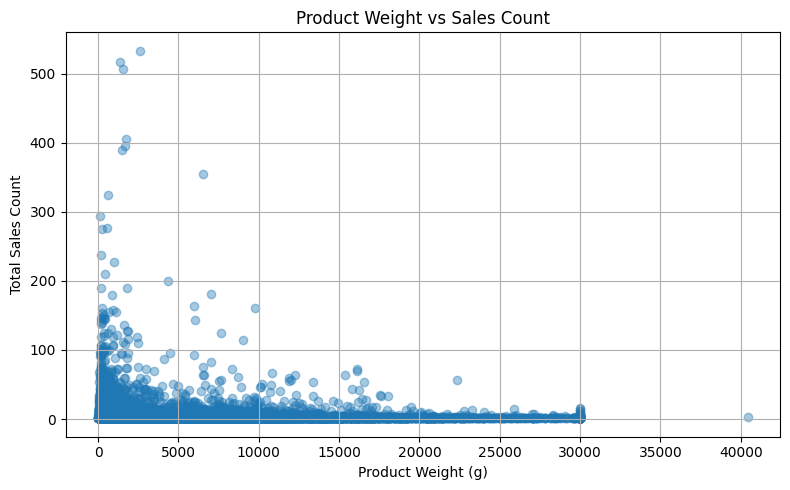

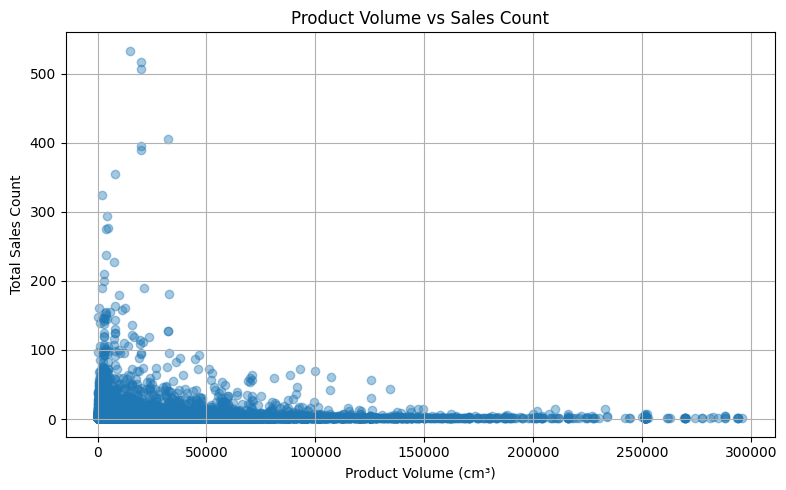

In [52]:
##EDA 1 KEEP
import matplotlib.pyplot as plt

# 2. Compute total sales per product.
product_sales = df_initial.groupby('product_id').size().reset_index(name='sales_count')

# 3. Extract each product’s size features (weight, length, width, height).
product_features = df_initial[[
    'product_id',
    'product_weight_g',
    'product_length_cm',
    'product_width_cm',
    'product_height_cm'
]].drop_duplicates()

# 4. Merge to get a DataFrame with:
#    product_id, weight, length, width, height, and sales_count.
prod_df = pd.merge(product_features, product_sales, on='product_id')

# 5. Drop any product rows where size information is missing.
prod_df = prod_df.dropna(subset=[
    'product_weight_g',
    'product_length_cm',
    'product_width_cm',
    'product_height_cm'
])

# 6. Compute “volume” as length × width × height.
prod_df['product_volume_cm3'] = (
    prod_df['product_length_cm']
    * prod_df['product_width_cm']
    * prod_df['product_height_cm']
)

# 7. Plot weight vs. sales_count
plt.figure(figsize=(8, 5))
plt.scatter(prod_df['product_weight_g'],
            prod_df['sales_count'],
            alpha=0.4)
plt.xlabel('Product Weight (g)')
plt.ylabel('Total Sales Count')
plt.title('Product Weight vs Sales Count')
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. Plot volume vs. sales_count
plt.figure(figsize=(8, 5))
plt.scatter(prod_df['product_volume_cm3'],
            prod_df['sales_count'],
            alpha=0.4)
plt.xlabel('Product Volume (cm³)')
plt.ylabel('Total Sales Count')
plt.title('Product Volume vs Sales Count')
plt.grid(True)
plt.tight_layout()
plt.show()

## EXPLANATION why we dropped the product size



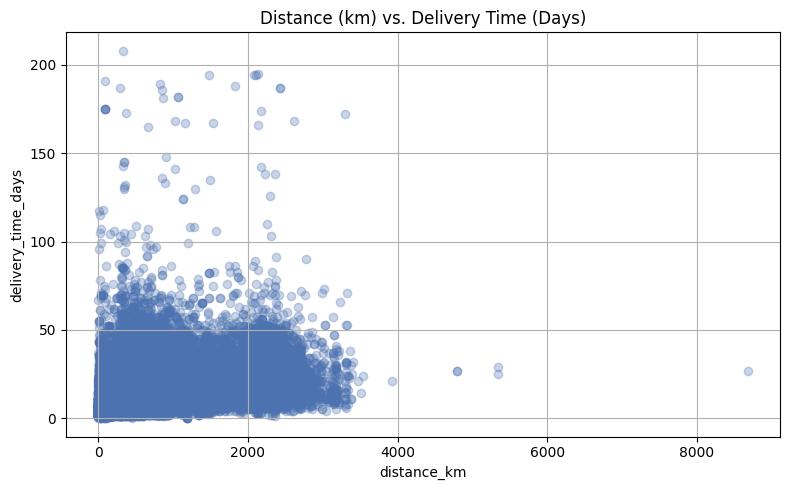

Correlation(distance_km, delivery_time_days): 0.39


In [53]:
# Cell 4: Scatter Plot – distance_km vs. delivery_time_days
plt.figure(figsize=(8, 5))
plt.scatter(
    delivered_df["distance_km"],
    delivered_df["delivery_time_days"],
    alpha=0.3,
    color="#4c72b0"
)
plt.title("Distance (km) vs. Delivery Time (Days)")
plt.xlabel("distance_km")
plt.ylabel("delivery_time_days")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute and print correlation
corr_dist_time = delivered_df[["distance_km", "delivery_time_days"]].corr().iloc[0, 1]
print(f"Correlation(distance_km, delivery_time_days): {corr_dist_time:.2f}")


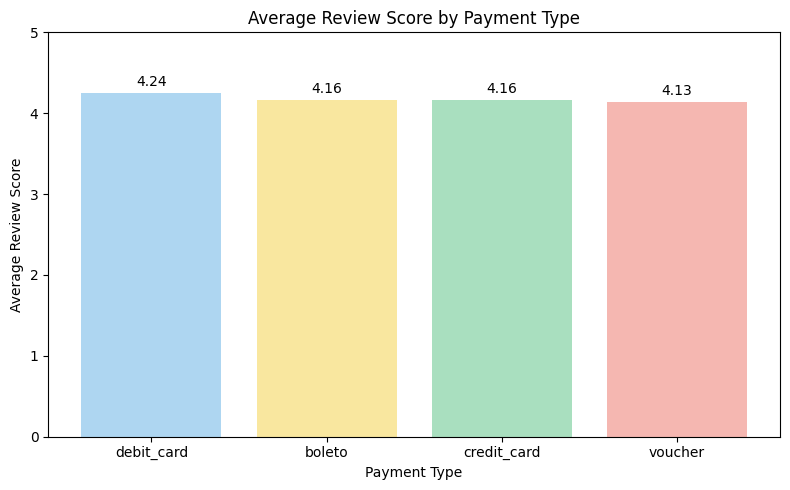

In [54]:
# 2. Convert delivered timestamp to datetime and filter to delivered orders
df_initial["order_delivered_customer_date"] = pd.to_datetime(
    df_initial["order_delivered_customer_date"], errors="coerce"
)

# 3. Drop rows missing either review_score or payment_type
delivered_reviews = delivered_df[
    delivered_df["review_score"].notna() & delivered_df["payment_type"].notna()
].copy()

# 4. Keep one row per order_id so each order appears exactly once
delivered_reviews_unique = delivered_reviews.drop_duplicates(subset=["order_id"])

# 5. Group by payment_type to compute average review_score
stats = (
    delivered_reviews_unique
    .groupby("payment_type")["review_score"]
    .mean()
    .reset_index(name="avg_review_score")
)

# 6. Optional: sort by avg_review_score if desired
stats = stats.sort_values("avg_review_score", ascending=False).reset_index(drop=True)

# 7. Plot a simple bar chart (no error bars) with y-axis from 0 to 5
plt.figure(figsize=(8, 5))

bars = plt.bar(
    stats["payment_type"],
    stats["avg_review_score"],
    color=["#AED6F1", "#F9E79F", "#A9DFBF", "#F5B7B1"],
)

# 8. Annotate each bar with its average review score (rounded to two decimals)
for idx, row in stats.iterrows():
    plt.text(
        idx,
        row["avg_review_score"] + 0.05,  # place label slightly above bar
        f"{row['avg_review_score']:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Average Review Score by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)  # Set scale from 0 to 5
plt.tight_layout()
plt.show()

In [55]:
print("Notebook shape:", merged_df.shape)
print(merged_df["repeat_buyer"].value_counts())

Notebook shape: (91497, 8)
repeat_buyer
0    88790
1     2707
Name: count, dtype: int64
